<h3 style="color: #3498db;"> 2.1.1 入门 </h3>

In [ ]:
#检测pytorch和cuda版本号
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [ ]:
y1=torch.zeros((2,3,4))#创建一个全零张量
y2=torch.ones((2,3,4))#创建一个全一张量

print(y1.shape)
print(y1.numel())


torch.Size([2, 3, 4])
24


In [ ]:
torch.randn(3,4)#创建一个服从标准正态分布的张量
torch.tensor([[2,1,4,3],[1,2,3,4],[4,3,2,1]])#赋予确定的元素值

tensor([[2, 1, 4, 3],
        [1, 2, 3, 4],
        [4, 3, 2, 1]])

<h3 style="color: #3498db;"> 2.1.2 运算符 </h3>

* **逐元素运算**：`+` `-` `*` `/` `**` 均为 Shape 严格对齐的逐元素操作，底层由 CUDA 万核并发执行。
* **拼接 (Concatenate)**：`torch.cat((X, Y), dim=d)` 沿第 `d` 维物理拼接，该维度长度相加，其余维度必须严格一致。
* **逻辑判断**：`X == Y` 逐元素比较，返回同 Shape 的布尔张量（`True/False`）。
* **全局求和**：`X.sum()` 将所有元素坍缩为单个标量张量，Shape 从 $(m, n)$ 降维至 $()$。

In [ ]:
x=torch.tensor([1.0,2,4,8])
y=torch.tensor([2,2,2,2])
x+y,x-y,x*y,x/y,x**y

torch.exp(x)

tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

In [ ]:
X=torch.arange(12,dtype=torch.float32).reshape((3,4))#定义X变量
Y=torch.tensor([[2.0,1,4,3],[1,2,3,4],[4,3,2,1]])#定义Y变量
torch.cat((X,Y),dim=0),torch.cat((X,Y),dim=1)#dim=0-行连结，dim=1-列连结

X==Y#判断是否相等，相等为true，否则为false

X.sum()#求和，变成一个单元素张量

tensor(66.)

<h3 style="color: #3498db;"> 2.1.3 广播机制 (Broadcasting) </h3>

**触发条件**：两个 Shape 不同的张量执行逐元素运算时，底层自动沿**长度为 1 的维度**进行虚拟复制对齐。

* **物理动作**：不实际分配新内存，仅在计算时"假装"沿缺失维度复制扩展，开销为零。
* **Strang 映射**：本质是向量空间中的外积式升维——列向量沿行方向广播 = 将 $\mathbb{R}^{m \times 1}$ 虚拟扩展为 $\mathbb{R}^{m \times n}$。
* **工程陷阱**：当两个张量的维度既不相等也不为 1 时，广播失败，直接抛出 Shape 不匹配的 RuntimeError。

In [ ]:
a=torch.arange(3).reshape((3,1))
b=torch.arange(2).reshape((1,2))
print(a,'\n',b)
a+b# a->3*2 ,b->3*2

tensor([[0],
        [1],
        [2]]) 
 tensor([[0, 1]])


tensor([[0, 1],
        [1, 2],
        [2, 3]])

<h3 style="color: #3498db;"> 2.1.4 索引和切片 </h3>

* **单点索引** `x[i, j]`：触发**维度坍缩**，被索引的维度直接消失，返回降维后的子张量。
* **切片索引** `x[i:j]`：**强制保留维度骨架**，即使只切出一个元素，Shape 中该维度仍以长度 1 存在。
* **左闭右开铁律**：`x[a:b]` 物理上提取索引 $[a, b)$，即包含 $a$ 但不包含 $b$。
* **赋值广播**：`x[0:2, :] = 12` 底层对右侧标量触发广播，批量覆写指定区域的所有元素。

In [ ]:
X[-1],X[1:3]#[-1]选择最后一行元素,[-3]选择第二行和第三行元素
X[1,2]=9#单元素赋值
X

X[0:2,:]=12
X

tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])

<h3 style="color: #3498db;"> 2.1.5 张量的内存管理 (In-place Operations) </h3>

**核心痛点**：非原地操作频繁开辟新显存，极易引发碎片化与 OOM 崩溃。

| 操作 | 底层机制 | 指针变化 | 显存开销 |
|------|----------|----------|----------|
| `Y = Y + X` | 新开辟完整内存，指针改向 | ✅ 改变 | 最差 |
| `Y[:] = Y + X` | 临时内存计算后拷贝回原地址 | ❌ 不变 | 峰值有开销 |
| `Y += X` / `Y.add_(X)` | 直接在原内存格子内覆写，零临时分配 | ❌ 不变 | **零额外开销，工程最优解** |

In [ ]:
before=id(Y)
Y=Y+X#非原地操作，重新分配内存
id(Y)==before#返回false

Y+=X#原地操作，内存地址不变
Y[:]=Y+X#同上
id(Y)==before

False

In [ ]:
#示例：
Z=torch.zeros_like(Y)
print('id(Z):',id(Z))
Z[:]=X+Y
print('id(Z):',id(Z))

id(Z): 2206177800208
id(Z): 2206177800208


<h3 style="color: #3498db;"> 2.1.6 转换为其他 Python 对象 </h3>

### 核心结论：三条 API 边界

| 场景 | API | 输出类型 | 底层行为 |
|------|-----|----------|----------|
| Tensor → NumPy | `.numpy()` | `np.ndarray` | **共享底层内存**，原地修改互相影响 |
| NumPy → Tensor | `torch.tensor(A)` | `torch.Tensor` | 同上，共享内存 |
| 单元素张量 → 纯数字 | `.item()` | Python `float/int` | 斩断计算图，安全提取（防 OOM）|
| 多元素张量 → 纯列表 | `.tolist()` | Python `list` | 批量剥离为原生嵌套列表 |

In [ ]:
#type()验证格式转换
A=X.numpy()
B=torch.tensor(A)
type(A),type(B)

(numpy.ndarray, torch.Tensor)

In [ ]:
#转换大小为1的张量
a=torch.tensor([3.5])
a,a.item(),float(a),int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

In [ ]:
x=torch.tensor([[1,2],[3,4]])
x[1,1].item()#提取单元素
x.tolist()#提取列表

[[1, 2], [3, 4]]

<h1 align="center"> 🛠️ 2.2 数据预处理 </h1>
<hr>

<h3 style="color: #3498db;"> 2.2.1 读取数据集 </h3>

### 1. 文件系统 I/O (`os` 模块)
* `os.path.join`：跨平台路径拼接，自动适配 `\` 或 `/`。`..` = 返回上一级父目录。
* `os.makedirs`：附带 `exist_ok=True`，目录已存在时静默跳过，不抛异常。
* `with open(...) as f`：上下文管理器，无论成功或报错，自动关闭文件句柄，杜绝资源泄漏。

### 2. Pandas 读取 (`pd.read_csv`)
* **工程定位**：Pandas 专司数据清洗脏活，清洗完毕后必须转化为 PyTorch Tensor 才能送入模型。
* **读取机制**：严格服从变量中的物理路径，自动解析首行为表头列名，自动将空缺内容映射为 `NaN`。

In [ ]:
#写入数据集
import os

os.makedirs(os.path.join('..','data'),exist_ok=True)
data_file=os.path.join('..','data','house_tiny.csv')
with open(data_file,'w') as f:
    f.write('NumRooms,Alley,Price\n')#列名
    f.write('NA,Pave,127500\n')#每行表示一个数据样本
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')


In [ ]:
#!pip install pandas #安装pandas
import pandas as pd
#读取数据集
data=pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


<h3 style="color: #3498db;"> 2.2.2 处理缺失值 (Data Preprocessing) </h3>
神经网络底层拒收缺失值（`NaN`）与文本。本节核心是将残缺业务表格淬炼为纯净张量：

### 1. 架构解耦 ($X$ 与 $Y$)
* **物理动作**：通过 `.iloc` 坐标切片，将数据强行切断为“输入特征 $X$” (`inputs`) 与“预测目标 $Y$” (`outputs`)。
* **工程铁律**：后续所有预处理只能针对 $X$。绝不允许 $Y$ 混入，严防数据泄露（Data Leakage）。

### 2. 均值插补 (数值特征)
* **物理动作**：调用 `.fillna()`，用数值列的**均值**覆盖 `NaN` 空洞，维持分布的“几何质心”。
* **断层规避**：Pandas 2.0+ 必须显式下达 `numeric_only=True` 指令，强制跳过非数值列。

### 3. 独热编码 (文本特征)
* **物理动作**：调用 `pd.get_dummies()`，将 $N$ 种文本状态撕裂为 $N$ 维正交基（独立的 0/1 特征列）。
* **情报固化**：开启 `dummy_na=True`，将 `NaN` 视为独立状态保留。在工业界，数据的缺失行为本身即是强特征。

In [ ]:
#神经网络架构Y=WX
# inputs 接管了第 0 列和第 1 列（房间数和巷子类型)--X
# outputs 独占了第 2 列（价格）--Y
inputs,outputs=data.iloc[:,0:2],data.iloc[:,2]
print(inputs.dtypes)
inputs=inputs.fillna(inputs.mean(numeric_only=True))
print(inputs)

NumRooms    float64
Alley        object
dtype: object
   NumRooms Alley
0       3.0  Pave
1       2.0   NaN
2       4.0   NaN
3       3.0   NaN


In [ ]:
#独热编码（One-Hot Encoding）
inputs=pd.get_dummies(inputs,dummy_na=True)
print(inputs)

   NumRooms  Alley_Pave  Alley_nan
0       3.0        True      False
1       2.0       False       True
2       4.0       False       True
3       3.0       False       True


<h3 style="color: #3498db;"> 2.2.3 转换为张量格式 (核心数据流) </h3>
数据在送入 GPU 前，必须经历三次**严格单向**的物理蜕变：

1. **Pandas DataFrame**（初始 `inputs`）：**业务清洗台**。保留列名，包容 `NaN` 和文本，专职负责特征解耦与清洗。
2. **NumPy Array**（`.to_numpy()` 算子）：**剥离业务属性**。强行扒掉列名与行号，退化为绝对纯粹的浮点数连续内存块。
3. **PyTorch Tensor**（`torch.tensor()`）：**GPU 算力弹药**。赋予底层求导（Gradient）器官，具备送入显卡执行万核并发矩阵乘法（$Y=WX$）的物理资格。

> **工程铁律**：Pandas 只干清洗脏活，Tensor 专责核心算力。物理边界森严，绝不混用。

In [ ]:
import torch
#注意：需先进行上文的独热编码，把文本撕裂成 True/False 的数字维度
X=torch.tensor(inputs.to_numpy(dtype=float))
y=torch.tensor(outputs.to_numpy(dtype=float))
X,y

(tensor([[3., 1., 0.],
         [2., 0., 1.],
         [4., 0., 1.],
         [3., 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

<h1 align="center"> 📐 2.3 线性代数 (Linear Algebra) </h1>
<hr>

<h3 style="color: #3498db;"> 2.3.1 标量——由单个元素表示 </h3>

In [ ]:
#单元素标量运算
import torch
x=torch.tensor(3.0)
y=torch.tensor(2.0)
x+y,x*y,x/y,x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

<h3 style="color: #3498db;"> 2.3.2 向量——一维张量 </h3>

In [ ]:
#创建一维张量
x=torch.arange(4)
x

tensor([0, 1, 2, 3])

In [ ]:
x[3]

tensor(3)

In [ ]:
len(x)#访问张量长度
x.shape#张量形状

torch.Size([4])

In [ ]:
A=torch.arange(20).reshape(5,4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

In [ ]:
A.T#转置

tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

In [ ]:
B=torch.tensor([[1,2,3],[2,0,4],[3,4,5]])
B

tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

In [ ]:
B==B.T#判断对称矩阵

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

<h3 style="color: #3498db;"> 2.3.4 张量 (Tensors) </h3>

**核心定义**：标量（0阶）、向量（1阶）、矩阵（2阶）向 $n$ 维坐标轴的物理泛化。

* **物理结构**：一段连续的底层显存，依靠 `Shape` 元组来决定如何“折叠”读取。例如 `reshape(2, 3, 4)` 意味着将 24 个元素在逻辑上切分为 2 大块，每块 3 行 4 列。
* **工程映射 (视觉领域)**：
  - 3 阶张量 `(C, H, W)`：单张图像（通道数, 高度, 宽度）。
  - 4 阶张量 `(B, C, H, W)`：深度学习标准数据流骨架，额外增加了批次大小（Batch Size）。
* **计算铁律**：不论张量达到多少阶，在 GPU 底层运算时，都会被完全拍平（Flatten）为一维连续数组进行并发计算。

In [ ]:
X=torch.arange(24).reshape(2,3,4)
X

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

<h3 style="color: #3498db;"> 2.3.5 张量算法的基本性质 </h3>

* **Hadamard 积 (`*`)**：严格的逐元素相乘。其核心数学特性是计算前后张量的**多维空间骨架（Shape）绝对守恒**，这与改变维度的矩阵点积运算（`@`）有本质物理区别。
* **标量运算的本质**：张量与标量（如 `a=2`）运算时，标量在底层被打包为 `()` 的 0 维张量，通过**广播机制**自动虚拟膨胀至相同维度，实现零额外开销的全局逐元素缩放。
* **显存硬隔离 (`.clone()`)**：强制在底层显存中开辟一块全新的物理内存进行深拷贝，彻底斩断与原张量的内存指针绑定，杜绝原地操作带来的连带污染。
* **广播机制物理约束**：无论维度多复杂，能否触发广播底层只看一条铁律——**从右向左逐维比对**，在每一层空间对齐上，两者长度必须“相等”或“其中之一严格等于 1”，否则立刻报错阻断计算。

In [ ]:
A=torch.arange(20,dtype=torch.float32).reshape(5,4)
B=A.clone()#通过分配新内存，将A的一个副本分配给B
A,A+B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.],
         [24., 26., 28., 30.],
         [32., 34., 36., 38.]]))

In [ ]:
A*B#Hadamard积,逐元素相乘

tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])

In [ ]:
a=2
X=torch.arange(24).reshape(2,3,4)
a+X,(a*X).shape

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

<h3 style="color: #3498db;"> 2.3.6 降维 </h3>

* **降维求和（Reduction）**：
  * 默认情况下，`.sum()` 沿所有轴将张量降维为一个标量。
  * 指定 `axis=0`（或 `dim=0`）沿行方向坍缩（纵向求和），消除第 0 维，得到 `(列数,)` 形状的向量。
  * 指定 `axis=1`（或 `dim=1`）沿列方向坍缩（横向求和），消除第 1 维，得到 `(行数,)` 形状的向量。
* **工程优化与防坑**：
  * **求和效率**：全局求和 `A.sum()` 性能优于 `A.sum(axis=[0, 1])`。前者直接调用全局规约算子 `sum_all`，无需步长寻址，开销极低；后者走通用的 `sum_dim` 分维度计算，带有 Python 参数解析与 C++ 步长元数据计算开销。
  * **均值计算**：计算平均值时应直接调用 `A.mean()`，严禁使用 `A.sum() / A.numel()`。原生 `mean` 仅需一次算子调度且底层会自动开启防溢出保护（如使用高精度累加器），而拼装法会带来三次调度开销，且在大张量下第一步 `sum()` 极易发生数值溢出（Overflow）爆成 `inf`。

In [ ]:
#单维求和
x=torch.arange(4,dtype=torch.float32)
x,x.sum()

(tensor([0., 1., 2., 3.]), tensor(6.))

In [ ]:
#多维求和，使用sum()函数默认沿所有轴降维求和--变成单一标量
A.shape,A.sum()

(torch.Size([5, 4]), tensor(190.))

In [ ]:
A_sum_axis0=A.sum(axis=0)#axis锁定轴0,加入keepdims=True保留一维
A_sum_axis0,A_sum_axis0.shape

(tensor([40., 45., 50., 55.]), torch.Size([4]))

In [ ]:
A_sum_axis1=A.sum(axis=1)#axis锁定轴1
A_sum_axis1,A_sum_axis1.shape

(tensor([ 6., 22., 38., 54., 70.]), torch.Size([5]))

In [ ]:
A.sum(axis=[0,1])#结果与A.sum()相同，但sum求和优于axis

tensor(190.)

In [ ]:
#求平均值
A.mean(),A.sum()/A.numel()#A.mean() 的性能和安全性都稳压 A.sum()/A.numel()

(tensor(9.5000), tensor(9.5000))

In [ ]:
#沿指定轴求平均值
A.mean(axis=0),A.sum(axis=0)/A.shape[0]#A.mean(axis=0) 在性能和安全性上依然完胜。

(tensor([ 8.,  9., 10., 11.]), tensor([ 8.,  9., 10., 11.]))

In [ ]:
#非降维求和
sum_A=A.sum(axis=1,keepdims=True)
sum_A

tensor([[ 6.],
        [22.],
        [38.],
        [54.],
        [70.]])

In [ ]:
A/sum_A

tensor([[0.0000, 0.1667, 0.3333, 0.5000],
        [0.1818, 0.2273, 0.2727, 0.3182],
        [0.2105, 0.2368, 0.2632, 0.2895],
        [0.2222, 0.2407, 0.2593, 0.2778],
        [0.2286, 0.2429, 0.2571, 0.2714]])

In [ ]:
A.cumsum(axis=0)#不会沿任何轴降低输入张量的维度

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  6.,  8., 10.],
        [12., 15., 18., 21.],
        [24., 28., 32., 36.],
        [40., 45., 50., 55.]])

<h3 style="color: #3498db;"> 2.3.7 点积 </h3>

* **基本定义与 API 约束**：
  * **数学定义**：点积（Dot Product）为相同位置按元素相乘的和，物理表达式为 $\mathbf{x}^\top \mathbf{y} = \sum_{i=1}^d x_i y_i$。
  * **API 约束**：`torch.dot(x, y)` 仅支持**两个一维向量**求点积。二维矩阵乘法必须使用 `torch.mm`、`torch.matmul` 或运算符 `@`。
* **性能差异与底层实现**：
  * **显存分配**：`torch.dot` 空间复杂度为 $O(1)$，通过寄存器在片上直接在线累加；而 `torch.sum(x * y)` 空间复杂度为 $O(N)$，需强行分配一块等大的临时内存存放中间乘积结果，浪费显存带宽。
  * **算子融合**：`torch.dot` 底层调用硬件高度优化的 BLAS 库（如 `cublasSdot`），是一体化的单内核（Kernel）操作；而拼装法需要分别调度乘法和求和两个 Kernel，多出一倍的通信调度延迟。
* **深度学习中的三大物理意义**：
  * **加权和（Weighted Sum）**：单个神经元整合不同特征（$\mathbf{x}^\top \mathbf{w}$）的基础计算形式。
  * **加权平均（Weighted Average）**：当权重非负且和为 1 时，点积退化为加权均值（如 Transformer 注意力分布对 Value 向量的加权整合）。
  * **夹角余弦（Cosine Similarity）**：向量规范化为单位长度后，点积公式 $\mathbf{a}^\top \mathbf{b} = \|\mathbf{a}\| \|\mathbf{b}\| \cos\theta$ 简化为 $\mathbf{u}^\top \mathbf{v} = \cos\theta$，即大模型 Embedding 语义相似度匹配的物理数学基石。

In [ ]:
y=torch.ones(4,dtype=torch.float32)
x,y,torch.dot(x,y)#dot用于求一维向量的点积（内积）

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.))

In [ ]:
torch.sum(x*y)#在性能和资源开销上，torch.dot(x, y) 完胜 torch.sum(x * y)

tensor(6.)

<h3 style="color: #3498db;"> 2.3.8 矩阵-向量积 </h3>

* **计算规则**：矩阵 $\mathbf{A} \in \mathbb{R}^{m \times n}$ 与向量 $\mathbf{x} \in \mathbb{R}^{n}$ 的乘积 $\mathbf{Ax}$，本质是用矩阵的每一行分别与向量 $\mathbf{x}$ 求一次点积，输出一个长度为 $m$ 的新向量。
* **Shape 变换**：$(m, n) \times (n,) \rightarrow (m,)$。矩阵的列数必须严格等于向量的长度，否则底层维度校验直接崩溃。
* **API**：`torch.mv(A, x)`，专用于二维矩阵与一维向量的乘积。
* **空间转换视角**：矩阵 $\mathbf{A}$ 充当线性映射（传送门），将 $n$ 维空间中的向量 $\mathbf{x}$ 投射到 $m$ 维空间中。输出结果被物理约束在矩阵 $\mathbf{A}$ 的列空间 $\mathcal{C}(A)$ 之内。

In [ ]:
A.shape,x.shape,torch.mv(A,x)#求向量积

(torch.Size([5, 4]), torch.Size([4]), tensor([ 14.,  38.,  62.,  86., 110.]))

<h3 style="color: #3498db;"> 2.3.9 矩阵-矩阵乘法 </h3>

* **空间变换规则**：$(n, k) \times (k, m) \rightarrow (n, m)$。内侧维度 $k$ 必须严丝合缝地物理对齐，本质是执行了 $m$ 次矩阵-向量积并横向拼接。
* **双重 API 工程生态**：
  * **`torch.mm(A, B)`（严格模式）**：极其死板，强制校验输入必须是标准的二维张量，常用于刻意拦截高维数据防止逻辑出错。
  * **`A @ B`（工程首选）**：底层调用 `torch.matmul`。它是具备智能嗅探的现代算子，能自动向下兼容点积与矩阵向量积，更能**向上支持带 Batch（批次）的高维批量矩阵乘法（BMM）**。在真实的大模型实操中，`@` 是绝对的标准写法。

In [ ]:
B=torch.ones(4,3)
torch.mm(A,B)#只接受二维张量

tensor([[ 6.,  6.,  6.],
        [22., 22., 22.],
        [38., 38., 38.],
        [54., 54., 54.],
        [70., 70., 70.]])

<h3 style="color: #3498db;"> 2.3.10 范数 </h3>

* **核心定义**：范数是"向量的长度"，把一个多元张量压缩成单一标量来衡量其"大小"。

* **两大核心范数对比**：

| 范数 | 公式 | API | 特性 |
|------|------|-----|------|
| $L_2$ 范数 | $\|\mathbf{x}\|_2 = \sqrt{\sum x_i^2}$ | `torch.norm(x)` | 对异常值极度敏感（平方放大） |
| $L_1$ 范数 | $\|\mathbf{x}\|_1 = \sum \|x_i\|$ | `torch.abs(x).sum()` | 对异常值鲁棒，倾向于将权重逼为 0（稀疏化） |

* **Frobenius 范数**：矩阵专属的"$L_2$ 范数"，将所有元素平方求和再开根号：$\|\mathbf{X}\|_F = \sqrt{\sum_{i,j} x_{ij}^2}$，调用方式与向量完全一致：`torch.norm(torch.ones((4, 9)))`。

* **范数在深度学习中的工程意义（正则化防过拟合）**：
  * **$L_2$ 正则化（权重衰减）**：对大权重惩罚更重，促使所有权重**均匀收缩变小**。底层等价于对 $A^TA$ 加上 $\lambda I$，强制恢复矩阵正定性，防止解空间崩塌。
  * **$L_1$ 正则化**：持续压榨小权重直到归零，自动完成**特征选择（稀疏化）**。
  * **深度学习的目标函数**本身通常就是一个范数：最小化预测值与真实值之间的 $L_2$ 距离。

In [ ]:
u=torch.tensor([3.0,-4.0])
torch.norm(u)

tensor(5.)

In [ ]:
torch.abs(u).sum()

tensor(7.)

<h1 align="center"> 📐 2.4 微积分 </h1>
<hr>

<h3 style="color: #3498db;"> 2.4.1 导数和微分 </h3>

In [ ]:
#通过令x=1并让h接近0，(2.4.1)中f(x+h)−f(x)的数值结果接近2
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

def f(x):
    return 3*x**2-4*x
def numerical_lim(f,x,h):
    return (f(x+h)-f(x))/h

h=0.1
for i in range(5):
    print(f'h={h:.5f},numerical limit={numerical_lim(f,1,h):.5f}')
    h*=0.1


h=0.10000,numerical limit=2.30000
h=0.01000,numerical limit=2.03000
h=0.00100,numerical limit=2.00300
h=0.00010,numerical limit=2.00030
h=0.00001,numerical limit=2.00003


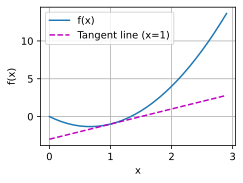

In [ ]:
#绘图
def use_svg_display():  #@save
    """"使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5,2.5)): #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize']=figsize

#@save
def set_axes(axes,xlabel,ylabel,xlim,ylim,xscale,yscale,legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

#@save
def plot(X,Y=None,xlabel=None,ylabel=None,legend=None,xlim=None,ylim=None,xscale='linear',yscale='linear',fmts=('-','m--','g--','r:'),figsize=(3.5,2.5),axes=None):
    """"绘制数据点"""
    if legend is None:
        legend=[]

    set_figsize(figsize)
    axes=axes if axes else d2l.plt.gca()

    #如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X,'ndim') and X.ndim==1 or isinstance(X,list)
                and not hasattr(X[0],'__len__'))
    
    if has_one_axis(X):
        X=[X]
    if Y is None:
        X,Y=[[]]*len(X),X
    elif has_one_axis(Y):
        Y=[Y]
    if len(X)!=len(Y):
        X=X*len(Y)
    axes.cla()
    for x,y,fmt in zip(X,Y,fmts):
        if len(X):
            axes.plot(x,y,fmt)
        else:
            axes.plot(y,fmt)
    set_axes(axes,xlabel,ylabel,xlim,ylim,xscale,yscale,legend)

x=np.arange(0,3,0.1)
plot(x,[f(x),2*x-3],'x','f(x)',legend=['f(x)','Tangent line (x=1)'])


<h3 style="color: #3498db;"> 2.4.2 偏导数 </h3>

In [ ]:
#略

<h3 style="color: #3498db;"> 2.4.3 梯度 (Gradient) </h3>

* **物理直觉**：梯度是多元函数偏导数的“打包向量”。在几何上，它永远指向当前地形（Loss曲面）中**最陡峭的上坡方向**。深度学习的“梯度下降算法”，本质就是沿着梯度的反方向走，去寻找误差的谷底。
* **数学定义**：$\nabla f(\mathbf{x}) = \left[ \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n} \right]^\top$。
* **最核心规则**：$\nabla_\mathbf{x} \Vert\mathbf{x}\Vert^2 = 2\mathbf{x}$。这是大模型中 $L_2$ 正则化（权重衰减）在反向传播时会对大权重产生强力惩罚的数学根基。

<h3 style="color: #3498db;"> 2.4.4 链式法则 (Chain Rule) </h3>
* **数学本质**：与高数中的多元复合函数求导完全等价，即把所有从自变量到因变量路径上的偏导数相乘并累加。
* **工程映射**：链式法则是神经网络**反向传播（Backpropagation）**的绝对引擎。在现代工程中，我们从不手算梯度，PyTorch 的 `autograd` 会在底层默默构建计算图，自动为你完成成千上万层的链式法则连乘计算。

<h3 style="color: #3498db;"> 2.4 练习 </h3>

1. 绘制函数$y=f(x)=x^3− \frac{1}{x}$和其在$x=1$处切线的图像

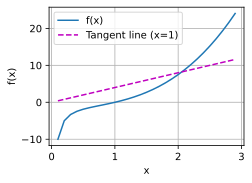

In [ ]:
x=np.arange(0.1,3,0.1)
def f(x):
    return x**3-1/x
plot(x,[f(x),4*x],'x','f(x)',legend=['f(x)','Tangent line (x=1)'])

2. 求函数$f(\mathbf{x})=3x_1^2+5e^{x_2}$的梯度

$\nabla f(\mathbf{x})=[6x_1,5e-{x_2}]$

3. 函数$f(x) = ∥x∥_2$的梯度是什么？

$\nabla f(\mathbf{x})=\frac{\mathbf{x}}{\mathbf{∥x∥}_2}$

<h3 style="color: #3498db;"> 2.5.1 反向传播 </h3>

In [ ]:
import torch
#创建初始值
x=torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [ ]:
x.requires_grad_(True)#挂载计算图，监控正向传播的路径
x.grad#默认值是None

In [ ]:
y=2*torch.dot(x,x)#点积
y

tensor(28., grad_fn=<MulBackward0>)

In [ ]:
y.backward()#反向传播，计算梯度
x.grad#储存梯度

tensor([ 0.,  4.,  8., 12.])

In [ ]:
x.grad==4*x#验证

tensor([True, True, True, True])

In [ ]:
#在默认情况下，Pytorch会累积梯度，我们需要清除之前的值
## 用 x.grad.zero_() 就够了，因为这里只有单个张量 x
x.grad.zero_()#第1步：把x.grad清零->[0.,0.,0.,0.]
y=x.sum()     #第2步：正向传播，y=x1+x2+x3+x4
y.backward()  #第3步:反向传播，把新梯度叠加进x.grad
x.grad        #第4步：读取结果
#工程上推荐用optimizer.zero_grad()

tensor([1., 1., 1., 1.])

<h3 style="color: #3498db;">正向与反向传播完整剖析</h3>

**例题设定：** $x=2,\quad a=x+1,\quad b=a^2,\quad y=3b$

| 阶段 | 节点 | 正向值 | 局部导数（便利贴） | 反向传入梯度 | 反向传出梯度 |
|:---:|:---:|:---:|:---:|:---:|:---:|
| ↓ 正向 | `[×3]` | $y=27$（Loss） | $\dfrac{\partial y}{\partial b}=3$ | $1$（起点） | $1\times3=3$ |
| ↓ 正向 | `[²]` | $b=9$ | $\dfrac{\partial b}{\partial a}=2a=6$（需存 $a=3$）| $3$ | $3\times6=18$ |
| ↓ 正向 | `[+1]` | $a=3$ | $\dfrac{\partial a}{\partial x}=1$ | $18$ | $18\times1=18 \rightarrow$ **x.grad** |

> **反向从下往上读**：每站传出梯度 = 传入梯度 × 局部导数（链式法则逐站连乘）

In [ ]:
#代码验证
import torch
x=torch.tensor(2.0,requires_grad=True)
x.grad
a=x+1
b=a**2
y=3*b
y.backward()
x.grad

tensor(18.)

<h3 style="color: #3498db;"> 2.5.2 非标量变量的反向传播 </h3>

在深度学习底层机制中，非标量反向传播的核心在于 **内存爆炸 vs 数学等价** 的物理权衡。

- **显式雅可比矩阵的 OOM 灾难**
  数学上，向量对向量求导的结果是巨大的雅可比矩阵（Jacobian）。如果特征维度达百万，该矩阵将占用数 TB 显存。因此 PyTorch 的铁律是：`backward()` 只能在纯标量上调用，拒绝生成完整矩阵。

- **工程解法：Vector-Jacobian Product (VJP) 降维打击**
  PyTorch 底层不生成雅可比矩阵，而是要求传入一个等长的梯度权重向量 $\mathbf{v}$，直接计算 $\mathbf{v}^\top J$ 实现降维。代码实现上有两种**物理等价**的方法：
  
  - **方法 B (显式传参)**：`y.backward(torch.ones(len(x)))` 
    手动传入全 $1$ 权重向量 $\mathbf{v}$。
  - **方法 A (隐式造标量，最常用)**：`y.sum().backward()`
    强行在计算图末尾增加加法标量节点 $z = \sum y_i$。由于加法的局部导数恒为 1 ($\frac{\partial z}{\partial y_i} = 1$)，这等同于在引擎内部**自动生成了方法 B 中的全 1 向量**并传递给雅可比矩阵，极其优雅地绕开了矩阵实例化。

- **自动微分 (AD) 的短视哲学与符号微分的困境**
  人类的本能是**符号微分**（保留完整的 $x^2$ 代数表达式），但若套用于百层网络（如 $x_{100}=x_{99}*x_{99}$），会导致恐怖的**表达式膨胀（Expression Swell）**，指数级耗尽内存。
  计算机使用的是**自动微分**：绝不保留代数公式，每到一站立即取出正向保存的具体数值（如 $x=0.5$）当场算出局部导数的纯浮点数，然后将其与传入梯度**严格仅做一次纯数字相乘**，单向完成接力传递。

In [ ]:
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y=x*x
# 等价于y.backward(torch.ones(len(x)
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

<h3 style="color: #3498db;"> 2.5.3 分离计算 (Detaching Computation) </h3>

在深度学习中（如训练 GAN 或冻结预训练特征层时），我们常常需要阻止梯度流经某些特定分支，这时候就要用到 `detach()` 操作。

- **`detach()` 的底层内存拓扑学**
  `u = y.detach()` 的物理动作是：**零拷贝复制数据，但彻底撕毁身世指针 (`grad_fn`)**。
  - `u` 拥有与 `y` 完全相同的数值（它们在底层共享同一块物理内存）。
  - 但 `u` 失去了与 $x$ 的因果联系。在自动微分引擎眼里，它退化成了一个没有任何过去的**纯粹常数**。

- **计算图的"树枝与枝杈"双缝实验**
  在 PyTorch 动态图（Define-by-Run）中，计算图是边运行边实时生长的。
  当执行 $y = x^3$ 时，从树根 $x$ 长出了树枝 $y$。
  当执行 $u = y.detach()$ 并用它计算 $z = u * x^2$ 时，由于 $u$ 只是常数，$z$ 并没有在 $y$ 这根树枝上继续往外长，而是拿着 $u$ 的数值作为系数，**另起炉灶，从树根 $x$ 处强行催生了一根全新的、完全独立的树枝 $z$**。
  
  这两个独立的分支不仅在数学上互不干扰，在物理图上也完美解耦：
  - **摇晃树枝 $y$（`y.backward()`）**：力顺着原始路径传回树根，对 $x$ 产生的导数为 $3x^2$。
  - **摇晃树枝 $z$（`z.backward()`）**：力顺着新路径传回树根。此时 $u$ 仅为常数系数，对 $x$ 产生的导数为 $u \cdot 2x = x^3 \cdot 2x = 2x^4$。
  
  **核心结论**：`y` 身上的计算图**一直活着**，从未被 `detach()` 破坏。

In [ ]:
x.grad.zero_()
y=x*x
u=y.detach()
z=u*x

z.sum().backward()
x.grad==u

tensor([True, True, True, True])

In [ ]:
x.grad.zero_()
y.sum().backward()
x.grad==2*x

tensor([True, True, True, True])

<h3 style="color: #3498db;"> 2.5.4 Python 控制流的梯度计算 </h3>

在老一辈深度学习框架（如初代 TensorFlow 的静态图）中，如果神经网络里有条件判断或循环，开发者绝对不能使用 Python 原生的 `if` 或 `while`，必须使用框架特制的晦涩 API。

PyTorch 引入了极其强大的 **动态计算图 (Define-by-Run)** 机制降维打击了这一切：
- 自动微分引擎是一个完全不懂逻辑控制的“跟屁虫”。
- 它不关心你的代码里写了什么 `if` 或 `while`，它只无脑记录**真实发生了的数学运算**。
- 如果代码循环了 3 次乘法，计算图上就会首尾相连 3 个乘法节点。如果程序走进了 `if` 分支，计算图就只记录 `if` 里的运算，`else` 分支直接被无视。

**核心结论**：每一次前向传播所生成的计算图，仅仅是 Python 代码当次**真实执行轨迹的物理克隆**。这赋予了深度学习工程师用原生 Python 编写任何极度复杂模型结构的绝对自由！

In [ ]:
def f(a):
    b=a*2
    while b.norm()<1000:
        b=b*2
    if b.sum()>0:
        c=b
    else:
        c=100*b
    return c

a=torch.randn(size=(),requires_grad=True)#size=()--生成一个空元组
d=f(a)
d.backward()
#a.grad==d/a--原书这段代码判断浮点数可能会出现精度丢失，而显示结果为false
torch.isclose(a.grad, d / a)#判断张量值是否接近---代替'=='

tensor(True)

<h3 style="color: #3498db;"> 2.5 练习 </h3>

In [ ]:
x=torch.arange(-3.14,3.14,0.1,requires_grad=True)
y=torch.sin(x)
y.sum().backward()

In [ ]:
x.grad

tensor([-1.0000, -0.9948, -0.9797, -0.9549, -0.9204, -0.8768, -0.8244, -0.7638,
        -0.6956, -0.6204, -0.5390, -0.4522, -0.3609, -0.2660, -0.1684, -0.0691,
         0.0308,  0.1304,  0.2288,  0.3248,  0.4176,  0.5062,  0.5898,  0.6675,
         0.7385,  0.8021,  0.8577,  0.9048,  0.9428,  0.9713,  0.9902,  0.9992,
         0.9982,  0.9872,  0.9664,  0.9359,  0.8961,  0.8473,  0.7900,  0.7248,
         0.6524,  0.5735,  0.4889,  0.3993,  0.3058,  0.2092,  0.1106,  0.0108,
        -0.0891, -0.1881, -0.2852, -0.3795, -0.4699, -0.5557, -0.6359, -0.7098,
        -0.7766, -0.8356, -0.8863, -0.9281, -0.9606, -0.9836, -0.9967])

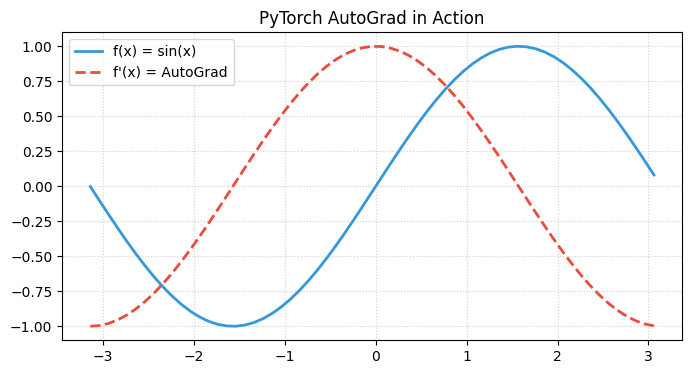

In [ ]:
import matplotlib.pyplot as plt

# 【工程铁律】：张量画图前，必须先物理剥离计算图 (detach)，再降级为 numpy 数组
x_np = x.detach().numpy()
y_np = y.detach().numpy()
grad_np = x.grad.numpy() # x.grad 是纯数据，默认没有计算图，但最好养成习惯也 detach 一下

# 设置画图画布
plt.figure(figsize=(8, 4))

# 画出正向传播的函数曲线 f(x) = sin(x)
plt.plot(x_np, y_np, label='f(x) = sin(x)', color='#3498db', linewidth=2)

# 画出自动微分算出来的梯度曲线（预期它应该是 cos(x) 的形状）
plt.plot(x_np, grad_np, label="f'(x) = AutoGrad", color='#e74c3c', linestyle='--', linewidth=2)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.title("PyTorch AutoGrad in Action")
plt.show()

<h3 style="color: #3498db;"> 2.6 概率论与统计 </h3>

**1. 随机采样与大数定律**
- **张量采样法则**：调用 `torch.multinomial`。引擎执行采样时严格继承输入概率张量的原始骨架，绝不越权升维。
- **物理收敛瓶颈**：随着样本数 $N$ 增加，理论方差严格按 $1/N$ 物理衰减；但现实可见的波动幅度（标准差）仅按 $1/\sqrt{N}$ 衰减。扩大 100 倍数据仅换来 10 倍精度，这是深度学习的物理代价。

**2. 边际概率与推土机降维**
- **物理引擎动作**：`x.sum(dim=x)` 的本质是**将指定的维度彻底碾碎并消除**。想要保留某个特征维度（例如保留行），就必须向它对立的、碍事的维度（列）开动推土机。

**3. 期望与方差的物理映射**
- **期望 $E[X]$**：代表点云在空间中的绝对重心（质心平移），对应底层算子 `x.mean()`。
- **方差 $Var[X]$**：代表点云固有的“胖度（离散拉伸能量）”。
  - **期望 $E$ 的绝对护盾**：计算距离平方后必须求平均（套上 $E$）。它是除以样本总数的粉碎机，确保点云胖度是一个绝对守恒的物理常量，防止能量随数据量暴涨而无限膨胀。
  - **工程师计算捷径**：$Var[X] = E[X^2] - (E[X])^2$。以极小内存开销一次性流式计算方差，避免显存 OOM。
- **标准差与量纲对齐**：方差消除了负数但强制平方了物理单位（量纲升维）。对结果开根号，是为了将误差重新降维至现实三维世界，实现物理意义上的量纲对齐。

**4. 贝叶斯定理与深度学习的终极架构**
- **基础概率谬误 (Base Rate Fallacy)**：当极高似然（机器 99% 准确率）遭遇极低先验（0.15% 患病率），庞大的基数将产生海量假阳性。贝叶斯定理本质是**新证据（似然）与旧常识（先验）在绝对物理数量上的残酷博弈**。
- **MAP 最大后验估计（Loss 的本质）**：
  对贝叶斯公式 $P(W|D) \propto P(D|W)P(W)$ 两边取**负对数 (Negative Log)**，乘法降维成安全的加法：
  - 数据似然 $P(D|W)$ 映射为 **CrossEntropyLoss（交叉熵损失，数据拟合度）**。
  - 先验常识 $P(W)$ 映射为 **L2 Regularization（权重衰减，防止过拟合的物理约束）**。
  每一次前向传播算出的 Loss，都是在这根贝叶斯拔河绳索上计算出的具体数值。

In [ ]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [ ]:
fair_probs=torch.ones([6])/6
multinomial.Multinomial(1,fair_probs).sample()

tensor([0., 0., 0., 0., 1., 0.])

In [ ]:
multinomial.Multinomial(10,fair_probs).sample()

tensor([3., 1., 2., 1., 1., 2.])

In [ ]:
#将结果储存为32位浮点数以进行除法
counts=multinomial.Multinomial(1000,fair_probs).sample()
counts/1000#相对频率作为估计值

tensor([0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.0000])

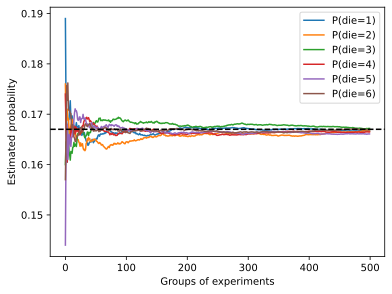

In [ ]:
counts=multinomial.Multinomial(1000,fair_probs).sample((500,))
cum_counts=counts.cumsum(dim=0)
estimates=cum_counts/cum_counts.sum(dim=1,keepdims=True)

d2l.set_figsize((6,4.5))
for i in range(6):
    d2l.plt.plot(estimates[:,i].numpy(),label=('P(die='+str(i+1)+')'))
d2l.plt.axhline(y=0.167,color='black',linestyle='dashed')
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend()

<h3 style="color: #3498db;"> 3.1.1 线性回归的基本元素 </h3>

- **核心模型体系与物理张量咬合**:
  - **数学公式**：$\hat{\mathbf{y}} = \mathbf{Xw} + b$
  - **张量维度铁律**：权重 $\mathbf{w}$ 的 Shape 仅由“特征数量”与“预测目标数”决定（单目标回归为 `(特征数, 1)`），绝对不受流水线输入样本量（Batch Size）的任何影响。
  - **广播机制**：偏置项标量 $b$ 自动调用底层 Broadcasting 机制，在内存中瞬间扩张至全量样本，实现“起步底价”的全局物理铺设。

- **损失函数（Loss Function）的底层机密**:
  - **均方误差（MSE）**：$l = \frac{1}{2} (\hat{y} - y)^2$。
  - **数学同源性**：深度学习的 MSE 在物理本质上 100% 等价于 Strang 线代体系中寻求正交投影误差极小化的 $\|y-Xw\|^2$。
  - **系数消音器**：常数 $\frac{1}{2}$ 是预设的“物理消音器”，专门用于在求一阶导数时完美抵消掉落下来的平方指数 `2`，以换取极其纯净的梯度公式。

- **从解析解到梯度下降（工业界的算力妥协）**:
  - **解析解（正规方程）**：$\mathbf{w}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$。数学理论完美，但求逆的时间复杂度高达 $O(d^3)$。当特征维度 $d$ 庞大时，会瞬间引发显卡 OOM（显存爆炸）与算力死锁。
  - **小批量随机梯度下降（Minibatch SGD）**：抛弃理论上完美的逆矩阵，改为每次抽取固定数量（$|B|$）的样本。在 GPU 底层利用 **VJP（矩阵转置相乘 $\mathbf{X}^\top e$）** 瞬间求出该批次的“集体平均梯度”，然后乘以学习率（$\eta$）指导模型反向下山。这是数学向硅基硬件妥协的终极产物。

- **模型的终极追求：泛化（Generalization）**:
  - 如果在训练集上把 Loss 强行逼近绝对的 0，会导致模型丧失物理规律，变成毫无意义的“死记硬背（过拟合）”。
  - **泛化**是指模型真正提炼出了数据背后的客观法则，使其在预测**从未见过的新生数据**时，依然能保持极低误差的能力。这是 AI 存在的唯一终极追求。

<h3 style="color: #3498db;"> 3.1.2 矢量化加速与计时引擎实测 </h3>

- **工程调试利器：Timer 计时类**
  - **核心物理机制**：底层基于 `time.time()` 提取 Unix 时间戳。利用 `__init__` 实现出厂即启动，利用 `stop()` 实现掐表、相减并归档。
  - **优雅输出**：搭配 Python 最强语法糖 **f-string**，例如 `f"{timer.stop():.5f} sec"`，冒号左边执行函数并吐出原始数据，冒号右边 `:.5f` 充当精度过滤器，强行裁切保留 5 位小数并拼接单位字符。

- **内存预分配（Pre-allocation）机制**
  - 在使用 `c[i] = ...` 这种循环逐个赋值前，必须提前执行 `c = torch.zeros(n)`。这是向操作系统强行申请一排长度为 $n$ 的物理空抽屉，否则底层会因为内存地址不存在而直接触发索引越界死锁。

- **核心铁律：矢量化加速（Vectorization）**
  - **反面教材（慢如蜗牛）**：在 Python 中写 `for i in range(n)` 来逐元素操作张量。由于 CPU 解释器必须在表层反复做寻址和类型检查，会造成极大的计算开销灾难（耗时 65 毫秒）。
  - **降维打击（瞬间吞噬）**：直接使用框架的张量运算 `c = a + b`。底层会自动绕过 Python，将加法指令整体打包砸进 C++ 或 CUDA 硬件层。数千个运算单元在同一个时钟周期内并发执行，耗时瞬间缩短至 0 毫秒（微秒级）。
  - **架构师原则**：只要操作张量，只要框架提供了整体计算的 API，就**绝对不要写 `for` 循环**！

In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

In [ ]:
n=10000
a=torch.ones([n])
b=torch.ones([n])

In [ ]:
class Timer: #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times=[]
        self.start()

    def start(self):
        """"启动计时器"""
        self.tik=time.time()

    def stop(self):
        """"停止计时器并将时间记录在列表中"""
        self.times.append(time.time()-self.tik)
        return self.times[-1]
    
    def avg(self):
        """"返回平均时间"""
        return sum(self.times)/len(self.times)
    
    def sum(self):
        """"返回时间总和"""
        return sum(self.times)
    
    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [ ]:
#第一种：
c=torch.zeros(n)
timer=Timer()
for i in range(n):
    c[i]=a[i]+b[i]
f'{timer.stop():.5f} sec'

'0.08133 sec'

In [ ]:
#第二种：
c=torch.zeros(n)
timer=Timer()
timer.start()
d=a+b
f'{timer.stop():.5f} sec'

'0.00000 sec'

<h3 style="color: #3498db;"> 3.1.3 正态分布和平方损失 </h3>

In [ ]:
def normal(x,mu,sigma):
    p=1/math.sqrt(2*math.pi*sigma**2)
    return p*np.exp(-0.5/sigma**2*(x-mu)**2)

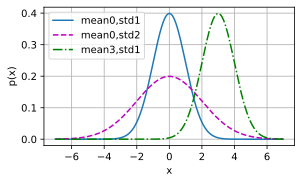

In [ ]:
#再次使用numpy进行可视化
x=np.arange(-7,7,0.01)

#均值和标准差对
params=[(0,1),(0,2),(3,1)]
d2l.plot(x,[normal(x,mu,sigma) for mu,sigma in params],xlabel='x',
         ylabel='p(x)',figsize=(4.5,2.5),
         legend=[f'mean{mu},std{sigma}' for mu,sigma in params])


<h3 style="color: #3498db;"> 3.2.1 生成数据集 </h3>

In [ ]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l


In [ ]:
def synthetic_data(w,b,num_examples): #save
    """"生成y=Xw+b+噪声"""
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1))

In [ ]:
true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)

print('features:',features[0],'\nlabel:',labels[0])

features: tensor([-0.5710, -0.0046]) 
label: tensor([3.0638])


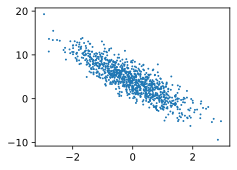

In [ ]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

<h3 style="color: #3498db;"> 3.2.2 读取数据集 </h3>

In [ ]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(
            indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]
batch_size=10

for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[-0.8328, -0.0055],
        [ 0.1409,  2.1029],
        [ 0.2040, -0.0845],
        [ 0.2745, -0.1845],
        [-0.5579,  1.0410],
        [ 1.2815, -0.0995],
        [-0.2991,  0.0315],
        [ 0.2433,  0.1824],
        [-0.8160, -0.9189],
        [ 1.1146, -2.6551]]) 
 tensor([[ 2.5452],
        [-2.6738],
        [ 4.8993],
        [ 5.3781],
        [-0.4382],
        [ 7.1136],
        [ 3.5091],
        [ 4.0537],
        [ 5.6900],
        [15.4730]])


<h3 style="color: #3498db;">  3.2.3 初始化模型参数 </h3>

In [ ]:
#加载两个计算图
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)


<h3 style="color: #3498db;"> 3.2.4 定义模型 </h3>

In [ ]:
def linreg(X,w,b): #save
    """线性回归模型"""
    return torch.matmul(X,w)+b

<h3 style="color: #3498db;"> 3.2.5 定义损失函数</h3>

In [ ]:
def squared_loss(y_hat,y): #save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape))**2/2

<h3 style="color: #3498db;"> 3.2.6 定义优化算法 </h3>

In [ ]:
def sgd(params,lr,batch_size): #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

<h3 style="color: #3498db;"> 3.2.7 训练 </h3>

In [ ]:
lr=0.03
num_epochs=3
net=linreg
loss=squared_loss
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y) #x和y的小批量损失
        #因为1形状是(batch_size,1),而不是一个标量。l中的所有元素被加到一起，
        #并以此计算关于[w,b]的梯度
        l.sum().backward()
    
        sgd([w,b],lr,batch_size) #使用参数的梯度更新参数
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch{epoch+1},loss{train_l.mean():f}')

epoch1,loss0.000053
epoch2,loss0.000053
epoch3,loss0.000053


In [ ]:
print(f'w的估计误差：{true_w-w.reshape(true_w.shape)}')
print(f'b的估计误差：{true_b-b}')

w的估计误差：tensor([-1.5736e-05, -9.2721e-04], grad_fn=<SubBackward0>)
b的估计误差：tensor([0.0008], grad_fn=<RsubBackward1>)


<h3 style="color: #3498db;"> 3.3.1 生成数据集 </h3>

In [1]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

In [2]:
true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=d2l.synthetic_data(true_w,true_b,1000)

<h3 style="color: #3498db;"> 3.3.2 读取数据集 </h3>

In [3]:
def load_array(data_arrays,batch_size,is_train=True): #@save
    """构造一个PyTorch数据迭代器"""
    dataset=data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=is_train)

In [4]:
batch_size=10
data_iter=load_array((features,labels),batch_size)

In [5]:
next(iter(data_iter))#切出第一批数据

[tensor([[ 2.6453,  0.5905],
         [ 0.0962, -0.1527],
         [ 0.0380, -1.0323],
         [ 0.1933, -0.7410],
         [ 0.8659, -0.0391],
         [ 0.9283, -0.4410],
         [ 0.3753,  0.1121],
         [-0.1926, -0.5625],
         [ 0.5612,  0.4521],
         [ 0.4307, -1.2427]]),
 tensor([[7.4799],
         [4.9043],
         [7.7811],
         [7.1164],
         [6.0692],
         [7.5493],
         [4.5832],
         [5.7231],
         [3.7944],
         [9.2951]])]

<h3 style="color: #3498db;"> 3.3.3 定义模型 </h3>

In [6]:
from torch import nn
net=nn.Sequential(nn.Linear(2,1))#Sequential--串联模块，

<h3 style="color: #3498db;"> 3.3.4 初始化模型参数 </h3>

In [7]:
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

tensor([0.])

<h3 style="color: #3498db;"> 3.3.5 定义损失函数 </h3>

In [8]:
loss=nn.MSELoss()

<h3 style="color: #3498db;"> 3.3.6 定义优化算法 </h3>

In [9]:
trainer=torch.optim.SGD(net.parameters(),lr=0.03)

<h3 style="color: #3498db;"> 3.3.7 训练 </h3>

In [10]:
num_epochs=3
for epoch in range(num_epochs):
    for X,y in data_iter:
        l=loss(net(X),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    with torch.no_grad():
        l=loss(net(features),labels)
        print(f'epoch{epoch+1},loss{l:f}')

epoch1,loss0.000226
epoch2,loss0.000101
epoch3,loss0.000100


In [11]:
w=net[0].weight.data
print('w的估计误差：',true_w-w.reshape(true_w.shape))
b=net[0].bias.data
print('b的估计误差:',true_b-b)

w的估计误差： tensor([-0.0006, -0.0004])
b的估计误差: tensor([0.0001])


<h3 style="color: #3498db;"> 3.4 Softmax 回归 </h3>

#### 1. 物理架构：全连接层与多目标输出
与预测连续数值的线性回归不同，Softmax 回归用于解决**离散多分类问题**。
- **网络结构**：每一个输出节点都必须接收所有的输入特征，这种密集的连接网被称为**全连接层**，其权重参数规模为 $O(dq)$。
- **矩阵运算**：在小批量（Mini-batch）下，正向传播的核心依然是标准的线性仿射变换：
  $$\mathbf{O} = \mathbf{XW} + \mathbf{b}$$
  其中输出矩阵 $\mathbf{O}$ 包含的是各个类别的原始绝对得分（Logits）。

#### 2. 核心工序：Softmax 算子与物理归一化
原始得分有正有负且无界，无法作为合法的概率。Softmax 算子通过两步将其强行映射为概率分布：
$$\hat{\mathbf{y}} = \text{softmax}(\mathbf{o}) \quad \text{其中} \quad \hat{y}_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$$
1. **取自然指数 $e^x$**：消灭所有负数，确保分子分母均为正。
2. **除以总和**：执行物理归一化，确保所有类别的预测概率加起来严格等于 1.0。
> **工程陷阱提醒**：Softmax 具有**保序性**（不改变原始得分的排名）。在严谨的数学定义中，它计算的是最大值所在的概率位置，因此它的本名其实是 **Soft-argmax**。真正的 Soft-max 是底层用于防止溢出的 `LogSumExp` 算子。

#### 3. 监控哨塔：交叉熵损失 (Cross-Entropy Loss)
分类问题的真实标签通常使用**独热编码 (One-Hot Encoding)**（例如 $[0, 1, 0]$）。为了度量预测概率与真实标签的差距，弃用 MSE，改用交叉熵：
$$l(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{j=1}^{q} y_j \log \hat{y}_j$$
- **运算极简机制**：由于 $\mathbf{y}$ 中只有正确答案所在的位置为 1，其余全为 0，这会导致巨大的求和公式瞬间坍缩。交叉熵在计算时实际上只看一个核心指标：**你把多少概率押在了正确的那个答案上**。押得越低，惩罚越重。
- **信息论视角**：交叉熵衡量的是“用模型预测的概率分布去编码真实分布时，所造成的物理存储空间开销差距”。

#### 4. 底层引擎大一统：极简的梯度回传
虽然正向传播经历了复杂的指数与对数运算，但在计算关于原始得分 $o_j$ 的偏导数时，复杂的公式恰好完美抵消，最终的梯度极其优雅：
$$\partial_{o_j} l(\mathbf{y}, \hat{\mathbf{y}}) = \hat{y}_j - y_j$$
即：**预测概率 减去 真实标签**。
这一结论与线性回归的求导结果完全同构，揭示了深度学习底层误差回传引擎的数学大一统。

<h3 style="color: #3498db;"> 3.5 图像分类数据集 </h3>

In [8]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l
d2l.use_svg_display()

In [9]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0～1之间
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
root="../data", train=False, transform=trans, download=True)

100.0%
100.0%
100.0%
100.0%


In [10]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [11]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [13]:
def get_fashion_mnist_labels(labels): #@save
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [16]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5): #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
        # 图片张量
            ax.imshow(img.numpy())
        else:
        # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

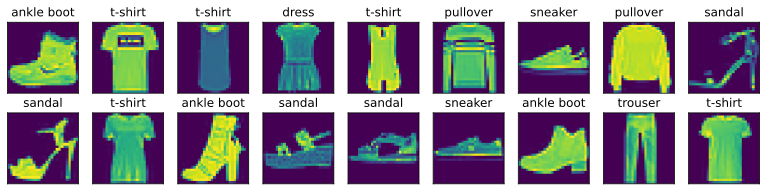

In [17]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y))

<h3 style="color: #3498db;"> 3.5.2 读取小批量 </h3>

In [18]:
batch_size=256

def get_dataloader_workers(): #@save
    """使用四个进程来读取数据"""
    return 4

train_iter=data.DataLoader(mnist_train,batch_size,shuffle=True,
                           num_workers=get_dataloader_workers())

timer=d2l.Timer()
for X,Y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'6.57 sec'

<h3 style="color: #3498db;"> 3.5.3 整合组件 </h3>

In [22]:
def load_data_fashion_mnist(batch_size,resize=None): #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans=[transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans=transforms.Compose(trans)
    mnist_train=torchvision.datasets.FashionMNIST(
        root="../data",train=True,transform=trans,download=True)
    mnist_test=torchvision.datasets.FashionMNIST(
        root="../data",train=False,transform=trans,download=True)
    return (data.DataLoader(mnist_train,batch_size,shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_train,batch_size,shuffle=False,
                            num_workers=get_dataloader_workers()))

In [23]:
train_iter,test_iter=load_data_fashion_mnist(32,resize=64)
for X,y in train_iter:
    print(X.shape,X.dtype,y.shape,y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


In [1]:
import torch
from IPython import display
from d2l import torch as d2l

In [2]:
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)

<h3 style="color: #3498db;"> 3.6.1 初始化模型参数 </h3>

In [3]:
num_inputs=784
num_outputs=10

In [9]:
W=torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)
b=torch.zeros(num_outputs,requires_grad=True)

<h3 style="color: #3498db;"> 3.6.2 定义softmax操作 </h3>

In [5]:
X=torch.tensor([[1.0,2.0,3.0],[4.0,5.0,6.0]])
X.sum(0,keepdim=True),X.sum(1,keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [6]:
def softmax(X):
    X_exp=torch.exp(X)
    partition=X_exp.sum(1,keepdim=True)
    return X_exp/partition #这里应用了广播机制

X=torch.normal(0,1,(2,5))
X_prob=softmax(X)
X_prob,X_prob.sum(1)

(tensor([[0.4421, 0.0532, 0.4048, 0.0657, 0.0342],
         [0.2969, 0.0179, 0.2137, 0.3850, 0.0865]]),
 tensor([1.0000, 1.0000]))

<h3 style="color: #3498db;"> 3.6.3 定义模型 </h3>

In [10]:
def net(X):
    return softmax(X.reshape(-1,W.shape[0])@W+b)

<h3 style="color: #3498db;"> 3.6.4 定义损失函数 </h3>

In [11]:
y=torch.tensor([0,2])
y_hat=torch.tensor([[0.1,0.3,0.6],[0.3,0.2,0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

In [16]:
def cross_entropy(y_hat,y):
    return -torch.log(y_hat[range(len(y_hat)),y])

cross_entropy(y_hat,y)

tensor([2.3026, 0.6931])

<h3 style="color: #3498db;"> 3.6.5 分类精度 </h3>

In [17]:
def accuracy(y_hat,y): #@save
    """计算预测正确的数量"""
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat=y_hat.argmax(axis=1)
    cmp=y_hat.type(y.dtype)==y
    return float(cmp.type(y.dtype).sum())

In [18]:
accuracy(y_hat,y)/len(y)

0.5

In [32]:
def evaluate_accuracy(net,data_iter): #@save
    """计算机在指定数据集上的模型精度"""
    if isinstance(net,torch.nn.Module):
        net.eval() #将模型设置为评估模式
    metric=Accumulator(2) #正确预测数、预测总数
    with torch.no_grad():
        for X,y in data_iter:
            metric.add(accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]

In [29]:
class Accumulator: #@save
    """在n个变量上累加"""
    def __init__(self,n):
        self.data=[0.0]*n

    def add(self,*args):
        self.data=[a+float(b) for a,b in zip(self.data,args)]

    def reset(self):
        self.data=[0.0]*len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]
    

In [33]:
evaluate_accuracy(net,test_iter)

0.0956

In [40]:
def train_epoch_ch3(net,train_iter,loss,updater): #@save
    """训练模型一个迭代周期"""
    if isinstance(net,torch.nn.Module):
        net.train()
    metric=Accumulator(3)
    for X,y in train_iter:
        #计算梯度并更新参数
        y_hat=net(X)
        l=loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer):
            #使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            #使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())
    #返回训练损失和训练精度
    return metric[0]/metric[2],metric[1]/metric[2]

In [47]:
class Animator: #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
# 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts
    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
                self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [60]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater): #@save
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [49]:
Ir=0.1

def updater(batch_size):
    return d2l.sgd([W,b],Ir,batch_size)

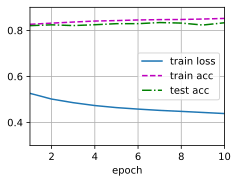

In [50]:
num_epochs=10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

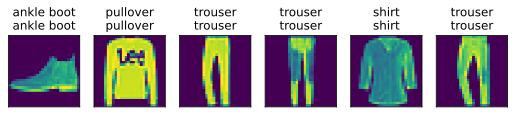

In [52]:
#预测
def predict_ch3(net, test_iter, n=6): #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
    X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])
predict_ch3(net, test_iter)

<h3 style="color: #3498db;"> 3.7 softmax回归的简洁实现 </h3>

In [54]:
import torch
from torch import nn
from d2l import torch as d2l

In [53]:
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)

<h3 style="color: #3498db;"> 3.7.1 初始化模型参数 </h3>

In [55]:
# PyTorch不会隐式地调整输入的形状。因此，
# 我们在线性层前定义了展平层（flatten），来调整网络输入的形状
net=nn.Sequential(nn.Flatten(),nn.Linear(784,10))

def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.normal_(m.weight,std=0.01)

net.apply(init_weights);

<h3 style="color: #3498db;"> 3.7.2 softmax的实现 </h3>

In [56]:
loss=nn.CrossEntropyLoss(reduction='none')

<h3 style="color: #3498db;"> 3.7.3 优化算法 </h3>

In [57]:
trainer=torch.optim.SGD(net.parameters(),lr=0.1)

<h3 style="color: #3498db;"> 3.7.4 训练 </h3>

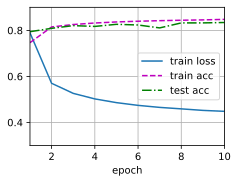

In [63]:
num_epochs=10
train_ch3(net,train_iter,test_iter,loss,num_epochs,trainer)